# Line chart: Access to clean fuels for cooking (Thailand, Indonesia, Myanmar, Laos, Cambodia, Vietnam)

In this notebook we recreate an Our World in Data (OWID)-style line chart showing the share of the population with access to clean fuels for cooking for six Southeast Asian countries. This workshop snapshot includes values for **2000** and **2023**.

Goals:
- Practice loading a CSV snapshot.
- Reshape data into tidy (long) format.
- Filter by country and year.
- Create a multi-line chart in Matplotlib with an OWID-like aesthetic.
- Check that the data cover the expected countries and years.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Matplotlib style settings (OWID-inspired)
plt.style.use("default")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [10]:
# Load OWID data from a local CSV in notebooks/data/
# Place the downloaded CSV at data/clean_fuels.csv (from OWID chart page: Download data -> CSV).

data_path = "data/clean_fuels.csv"
df = pd.read_csv(data_path)
df.head()


,Country or region,2000,2023,1990–2023,Absolute Change (pp),Relative Change
0,Thailand,59.90%,86.80%,NaN,26.9,45%
1,Vietnam,13.20%,98.70%,NaN,85.5,648%
2,Indonesia,6.70%,90.60%,NaN,83.9,1252%
3,Cambodia,3.40%,58.00%,NaN,54.6,1606%
4,Myanmar,1.70%,53.50%,NaN,51.8,3047%


In [11]:
# Inspect columns and basic info (tidy data check)

print(df.columns)
print()
print(df.info())


Index(['Country or region', '2000', '2023', '1990–2023',
       'Absolute Change (pp)', 'Relative Change'],
      dtype='object')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Country or region     6 non-null      object 
 1   2000                  6 non-null      object 
 2   2023                  6 non-null      object 
 3   1990–2023             0 non-null      float64
 4   Absolute Change (pp)  6 non-null      float64
 5   Relative Change       6 non-null      object 
dtypes: float64(2), object(4)
memory usage: 416.0+ bytes
None


In [12]:
# Reshape the snapshot to tidy format and add ISO country codes

country_codes = ["THA", "VNM", "IDN", "KHM", "MMR", "LAO"]

country_to_code = {
    "Thailand": "THA",
    "Vietnam": "VNM",
    "Indonesia": "IDN",
    "Cambodia": "KHM",
    "Myanmar": "MMR",
    "Laos": "LAO",
}

# Keep only year columns from the snapshot (e.g. 2000 and 2023)
year_cols = [c for c in df.columns if str(c).isdigit()]

df_long = df.melt(
    id_vars=["Country or region"],
    value_vars=year_cols,
    var_name="Year",
    value_name="clean_fuels_pct",
)

df_long["Year"] = df_long["Year"].astype(int)

df_long["clean_fuels_pct"] = (
    df_long["clean_fuels_pct"].astype(str).str.replace("%", "", regex=False).astype(float)
)

df_long = df_long.rename(columns={"Country or region": "Entity"})
df_long["Code"] = df_long["Entity"].map(country_to_code)

# Filter to expected countries/years
start_year = 2000
end_year = 2023

df_sel = df_long[df_long["Code"].isin(country_codes)].copy()
df_sel = df_sel[(df_sel["Year"] >= start_year) & (df_sel["Year"] <= end_year)]

# Simple assertions to verify coverage
assert set(df_sel["Code"].unique()) == set(country_codes), "Unexpected country codes in filtered data"
assert df_sel["Year"].min() == start_year, "Earliest year is not 2000"
assert df_sel["Year"].max() == end_year, "Latest year is not 2023"

df_sel.head()


,Entity,Year,clean_fuels_pct,Code
0,Thailand,2000,59.9,THA
1,Vietnam,2000,13.2,VNM
2,Indonesia,2000,6.7,IDN
3,Cambodia,2000,3.4,KHM
4,Myanmar,2000,1.7,MMR


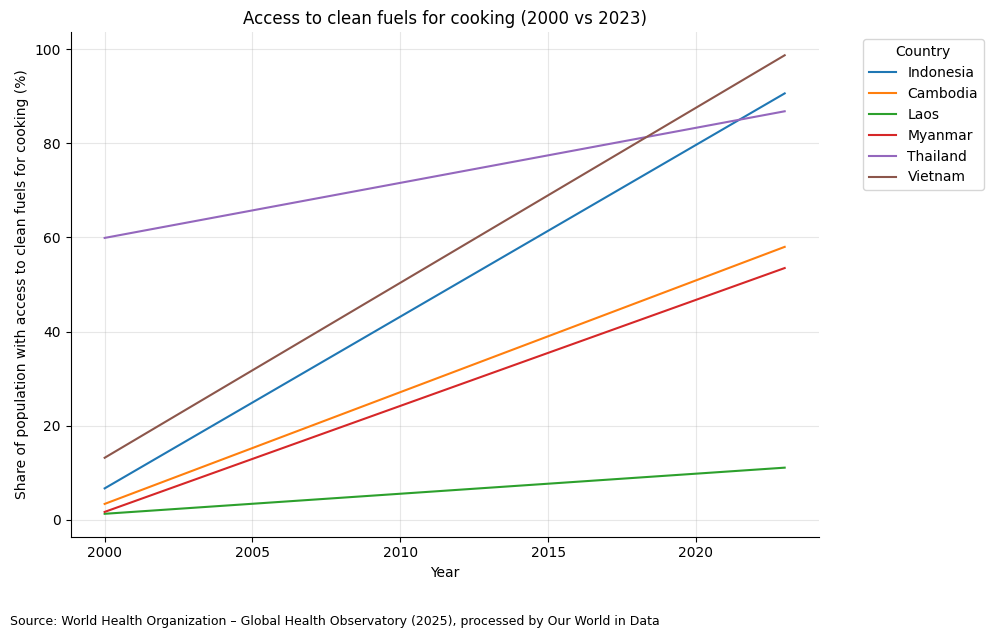

In [13]:
# Plot multi-country line chart (OWID-style)

indicator_col = "clean_fuels_pct"

fig, ax = plt.subplots()

for code, group in df_sel.groupby("Code"):
    country_name = group["Entity"].iloc[0]
    ax.plot(group["Year"], group[indicator_col], label=country_name)

ax.set_xlabel("Year")
ax.set_ylabel("Share of population with access to clean fuels for cooking (%)")
ax.set_title("Access to clean fuels for cooking (2000 vs 2023)")

# Place legend outside the plot on the right
ax.legend(title="Country", bbox_to_anchor=(1.05, 1), loc="upper left")

# Add a short source line below the chart
plt.figtext(
    0.01,
    -0.05,
    "Source: World Health Organization – Global Health Observatory (2025), processed by Our World in Data",
    ha="left",
    fontsize=9,
)

plt.tight_layout()
plt.show()


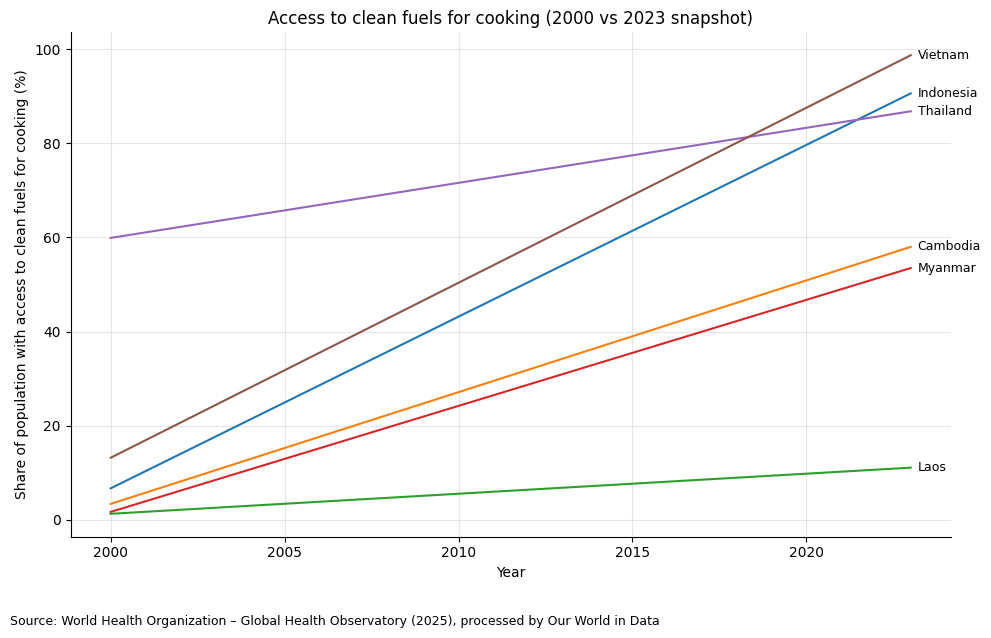

In [16]:
# Plot multi-country line chart (OWID-style)
indicator_col = "clean_fuels_pct"
fig, ax = plt.subplots()
for code, group in df_sel.groupby("Code"):
    group_sorted = group.sort_values("Year")
    country_name = group_sorted["Entity"].iloc[0]
    # Plot the line
    ax.plot(group_sorted["Year"], group_sorted[indicator_col], label=country_name)
    # Label at the last point
    last_x = group_sorted["Year"].iloc[-1]
    last_y = group_sorted[indicator_col].iloc[-1]
    ax.text(
        last_x + 0.2,  # nudge right so it doesn’t overlap the marker
        last_y,
        country_name,
        va="center",
        fontsize=9,
    )
ax.set_xlabel("Year")
ax.set_ylabel("Share of population with access to clean fuels for cooking (%)")
ax.set_title("Access to clean fuels for cooking (2000 vs 2023 snapshot)")
# Remove legend (labels are on the lines)
ax.legend().remove()
plt.figtext(
    0.01,
    -0.05,
    "Source: World Health Organization – Global Health Observatory (2025), processed by Our World in Data",
    ha="left",
    fontsize=9,
)
plt.tight_layout()
plt.show()

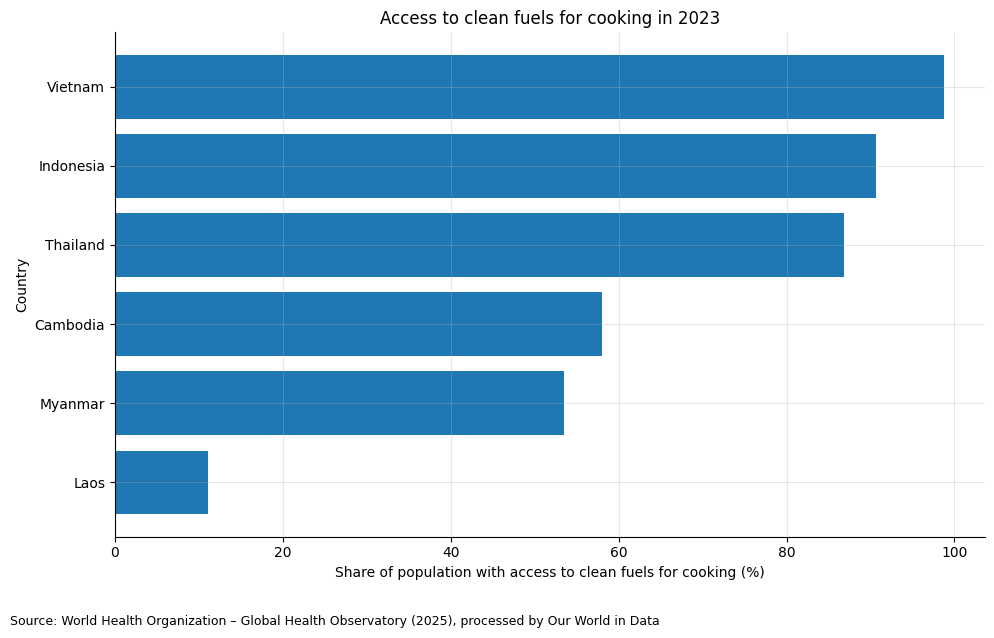

In [14]:
# Bar chart: access to clean fuels in 2023

# Filter the tidy data to 2023 only
bar_2023 = df_sel[df_sel["Year"] == 2023].copy()

# Sort by value for a cleaner bar chart
bar_2023 = bar_2023.sort_values("clean_fuels_pct", ascending=True)

fig, ax = plt.subplots()

ax.barh(bar_2023["Entity"], bar_2023["clean_fuels_pct"])

ax.set_xlabel("Share of population with access to clean fuels for cooking (%)")
ax.set_ylabel("Country")
ax.set_title("Access to clean fuels for cooking in 2023")

# Add source line below the chart
plt.figtext(
    0.01,
    -0.05,
    "Source: World Health Organization – Global Health Observatory (2025), processed by Our World in Data",
    ha="left",
    fontsize=9,
)

plt.tight_layout()
plt.show()

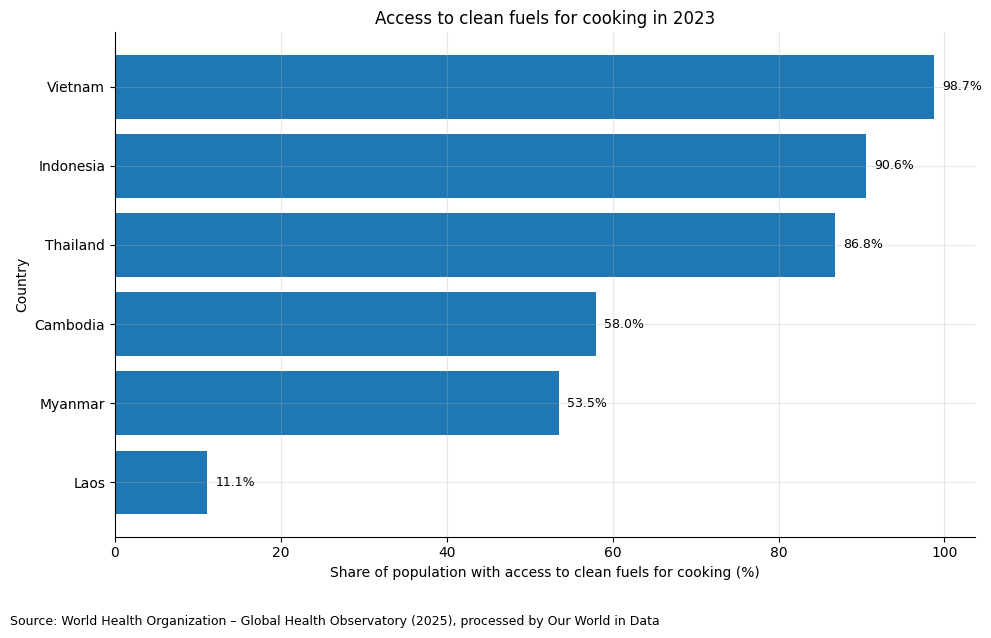

In [15]:
# Bar chart: access to clean fuels in 2023

# Filter the tidy data to 2023 only
bar_2023 = df_sel[df_sel["Year"] == 2023].copy()

# Sort by value for a cleaner bar chart
bar_2023 = bar_2023.sort_values("clean_fuels_pct", ascending=True)

fig, ax = plt.subplots()
bars = ax.barh(bar_2023["Entity"], bar_2023["clean_fuels_pct"])
ax.set_xlabel("Share of population with access to clean fuels for cooking (%)")
ax.set_ylabel("Country")
ax.set_title("Access to clean fuels for cooking in 2023")
# Add value labels at the end of each bar
for bar, value in zip(bars, bar_2023["clean_fuels_pct"]):
    width = bar.get_width()
    ax.text(
        width + 1,                      # a bit to the right of the bar
        bar.get_y() + bar.get_height()/2,
        f"{value:.1f}%",                # e.g. 86.8%
        va="center",
        fontsize=9,
    )
# Add source line below the chart
plt.figtext(
    0.01,
    -0.05,
    "Source: World Health Organization – Global Health Observatory (2025), processed by Our World in Data",
    ha="left",
    fontsize=9,
)
plt.tight_layout()
plt.show()

## Licensing, attribution, and how to obtain the data

- Data and original interactive chart: Our World in Data, "Share of the population with access to clean fuels for cooking" (`access-to-clean-fuels-and-technologies-for-cooking`).
- Original data provider: World Health Organization – Global Health Observatory (GHO).
- OWID and its code/visualizations are released under [Creative Commons BY](https://ourworldindata.org/grapher/access-to-clean-fuels-and-technologies-for-cooking#reuse); original providers retain their own licenses.

To obtain the CSV and use it in this notebook:
1. Open the [OWID chart page](https://ourworldindata.org/grapher/access-to-clean-fuels-and-technologies-for-cooking) in your browser.
2. Click **"Download"** (or **"Data"** tab) and choose **CSV**.
3. Save the file as `data/clean_fuels.csv` in the same folder as this notebook (i.e. `notebooks/data/clean_fuels.csv`).
4. Re-run the notebook; it will load from this local file.
